# Dumbbells with / without arms – model comparison
#
This notebook:
Loads pairs of images (with_arms / without_arms)
* Runs several ImageNet models:
     - Lucent InceptionV1 (Inception5h)
     - ResNet‑50 (torchvision)
     - GoogLeNet (torchvision)
* Computes:
     - top‑1 predictions
     - dumbbell probability (with and without arms)
     - deltas (without − with)
* Builds a DataFrame with results
* Plots a heatmap and bar charts of how dumbbell probability changes

In [1]:
import os
import sys
from pathlib import Path

import torch
import torch.nn.functional as F
from torchvision import transforms
from torchvision.models import resnet50, googlenet
from PIL import Image

import matplotlib.pyplot as plt
import pandas as pd

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# --- Paths: adjust if needed ---

# Locate repo root relative to this file when possible; fallback to CWD in notebooks
REPO_ROOT = Path(__file__).resolve().parents[2] if "__file__" in globals() else Path.cwd().parents[1]
print(REPO_ROOT)
# Dataset path: <repo_root>/datasets/dumbbell_and_arms
DATA_ROOT = REPO_ROOT / "datasets" / "dumbbells_and_arms"
print(DATA_ROOT)
# Path to your lucent checkout
LUCENT_ROOT = Path(
    "/Users/juliawenkmann/Documents/CodingProjects/damien/"
    "sophia_summit/sophia_summit_presentation/src/lucent"
)

if str(LUCENT_ROOT) not in sys.path:
    sys.path.insert(0, str(LUCENT_ROOT))

from lucent.modelzoo import inceptionv1


Using device: cpu
/Users/juliawenkmann/Documents/CodingProjects/damien/xai-reproductions
/Users/juliawenkmann/Documents/CodingProjects/damien/xai-reproductions/datasets/dumbbells_and_arms


## Load labels and find dumbbell index

In [2]:
imagenet_classes_file = REPO_ROOT / "imagenet_classes.txt"
lucent_label_file = LUCENT_ROOT / "lucent" / "modelzoo" / "misc" / "imagenet_labels.txt"

if not imagenet_classes_file.is_file() and lucent_label_file.is_file():
    imagenet_classes_file = lucent_label_file

if imagenet_classes_file.is_file():
    with open(imagenet_classes_file) as f:
        IDX2LABEL = [line.strip() for line in f]
    print(f"Loaded {len(IDX2LABEL)} labels from {imagenet_classes_file}")
else:
    IDX2LABEL = None
    print("WARNING: no label file found, class names will be 'class_<idx>'")


def idx_to_label(idx: int) -> str:
    if IDX2LABEL is None or idx < 0 or idx >= len(IDX2LABEL):
        return f"class_{idx}"
    return IDX2LABEL[idx]


def find_dumbbell_index():
    """Locate 'dumbbell' in the label list."""
    if IDX2LABEL is None:
        print("No label file found, falling back to index 543 for 'dumbbell'.")
        return 543

    matches = [i for i, name in enumerate(IDX2LABEL)
               if "dumbbell" in name.lower()]
    if not matches:
        raise ValueError("Couldn't find 'dumbbell' in labels file.")

    idx = matches[0]
    print(f"Using dumbbell index {idx}: {IDX2LABEL[idx]}")
    return idx


DUMBBELL_IDX = find_dumbbell_index()


# %% Preprocessing pipelines & image loader

input_size = 224

# Inception5h (Lucent InceptionV1) preprocessing.
# TF version uses IMAGE_MEAN = 117, IMAGE_STD = 1 on 0–255 pixels.
# ToTensor() -> [0,1], so we choose mean=117/255, std=1/255:
# (x - 117/255) / (1/255) = 255 * x - 117
INCEPTION_MEAN = 117.0 / 255.0
INCEPTION_STD = 1.0 / 255.0

preprocess_inception = transforms.Compose([
    transforms.Resize(int(input_size * 256 / 224)),
    transforms.CenterCrop(input_size),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[INCEPTION_MEAN] * 3,
        std=[INCEPTION_STD] * 3,
    ),
])

# Standard ImageNet preprocessing for torchvision models
preprocess_tv = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])


def load_image_tensor(path: Path, preprocess) -> torch.Tensor:
    img = Image.open(path).convert("RGB")
    return preprocess(img).unsqueeze(0).to(device)

Loaded 1000 labels from /Users/juliawenkmann/Documents/CodingProjects/damien/sophia_summit/sophia_summit_presentation/src/lucent/lucent/modelzoo/misc/imagenet_labels.txt
Using dumbbell index 543: 543 dumbbell


## Build models

In [3]:
# Lucent InceptionV1
lucent_inception = inceptionv1.inceptionv1(pretrained=True).to(device).eval()


# Torchvision models (with compatibility for older / newer APIs)
def build_torchvision_models(device):
    try:
        from torchvision.models import ResNet50_Weights, GoogLeNet_Weights

        m_resnet = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
        m_goog = googlenet(weights=GoogLeNet_Weights.IMAGENET1K_V1,
                           aux_logits=True)
    except Exception:
        m_resnet = resnet50(pretrained=True)
        m_goog = googlenet(pretrained=True, aux_logits=True)

    m_resnet.to(device).eval()
    m_goog.to(device).eval()
    return {
        "resnet50": m_resnet,
        "torchvision_googlenet": m_goog,
    }


tv_models = build_torchvision_models(device)

# Collect all models + their preprocess functions
all_models = {
    "lucent_inceptionv1": (lucent_inception, preprocess_inception),
    "resnet50": (tv_models["resnet50"], preprocess_tv),
    "torchvision_googlenet": (tv_models["torchvision_googlenet"], preprocess_tv),
}

print("Models:", list(all_models.keys()))


# %% Classification helper

def forward_logits(model, x: torch.Tensor) -> torch.Tensor:
    with torch.no_grad():
        out = model(x)
    if isinstance(out, (tuple, list)):
        out = out[0]
    return out


def classify_and_score_image(
    img_path: Path,
    model,
    preprocess,
    dumbbell_idx: int,
):
    """Run one image through one model."""
    x = load_image_tensor(img_path, preprocess)
    logits = forward_logits(model, x)
    probs = F.softmax(logits, dim=1)

    # Top‑5 predictions
    top_prob, top_idx = probs.topk(5, dim=1)
    top_prob = top_prob.squeeze(0).cpu().numpy()
    top_idx = top_idx.squeeze(0).cpu().numpy()

    top5 = []
    for p, idx in zip(top_prob, top_idx):
        idx_int = int(idx)
        top5.append((idx_int, idx_to_label(idx_int), float(p)))

    if dumbbell_idx >= logits.shape[1]:
        dumbbell_logit = float("nan")
        dumbbell_prob = float("nan")
    else:
        dumbbell_logit = logits[0, dumbbell_idx].item()
        dumbbell_prob = probs[0, dumbbell_idx].item()

    return {
        "top5": top5,
        "dumbbell_logit": dumbbell_logit,
        "dumbbell_prob": dumbbell_prob,
    }


Models: ['lucent_inceptionv1', 'resnet50', 'torchvision_googlenet']


/Users/juliawenkmann/miniconda3/envs/ml/lib/python3.11/site-packages/torchvision/models/googlenet.py:341: UserWarning: auxiliary heads in the pretrained googlenet model are NOT pretrained, so make sure to train them
  warnings.warn(


## Collect image pairs (with_arms / without_arms)

In [4]:
with_dir = DATA_ROOT / "with_arms"
without_dir = DATA_ROOT / "without_arms"

valid_exts = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

with_files = {
    p.name: p for p in with_dir.iterdir()
    if p.suffix.lower() in valid_exts
}
without_files = {
    p.name: p for p in without_dir.iterdir()
    if p.suffix.lower() in valid_exts
}

common_names = sorted(set(with_files.keys()) & set(without_files.keys()))
print(f"Found {len(common_names)} matching image pairs.")
display(common_names)


Found 6 matching image pairs.


['img_0.jpg', 'img_1.jpg', 'img_2.jpg', 'img_3.jpg', 'img_4.jpg', 'img_5.jpg']

## Run all models on all pairs and build DataFrame

In [5]:
rows = []

for name in common_names:
    print(f"\n=== {name} ===")
    for model_name, (model, preprocess) in all_models.items():
        result_with = classify_and_score_image(
            with_files[name], model, preprocess, DUMBBELL_IDX
        )
        result_without = classify_and_score_image(
            without_files[name], model, preprocess, DUMBBELL_IDX
        )

        top1_with = result_with["top5"][0]
        top1_without = result_without["top5"][0]

        row = {
            "image": name,
            "model": model_name,
            "with_top1_label": top1_with[1],
            "with_top1_prob": top1_with[2],
            "without_top1_label": top1_without[1],
            "without_top1_prob": top1_without[2],
            "with_dumbbell_prob": result_with["dumbbell_prob"],
            "without_dumbbell_prob": result_without["dumbbell_prob"],
            "delta_dumbbell_prob": (
                result_without["dumbbell_prob"] - result_with["dumbbell_prob"]
            ),
            "with_dumbbell_logit": result_with["dumbbell_logit"],
            "without_dumbbell_logit": result_without["dumbbell_logit"],
            "delta_dumbbell_logit": (
                result_without["dumbbell_logit"] - result_with["dumbbell_logit"]
            ),
        }
        rows.append(row)

        print(
            f"[{model_name}] "
            f"top1 WITH: {top1_with[1]} ({top1_with[2]:.3f}) | "
            f"top1 WITHOUT: {top1_without[1]} ({top1_without[2]:.3f}) | "
            f"dumbbell WITH: {result_with['dumbbell_prob']:.3f}, "
            f"WITHOUT: {result_without['dumbbell_prob']:.3f}, "
            f"Δprob: {row['delta_dumbbell_prob']:+.3f}"
        )

df = pd.DataFrame(rows)
df


summary = df.groupby("model")["delta_dumbbell_prob"].mean().sort_values(ascending=False)
summary




=== img_0.jpg ===
[lucent_inceptionv1] top1 WITH: 567 frying pan, frypan, skillet (0.003) | top1 WITHOUT: class_1000 (0.003) | dumbbell WITH: 0.001, WITHOUT: 0.001, Δprob: +0.000
[resnet50] top1 WITH: 571 gas pump, gasoline pump, petrol pump, island dispenser (0.112) | top1 WITHOUT: 543 dumbbell (0.196) | dumbbell WITH: 0.107, WITHOUT: 0.196, Δprob: +0.089
[torchvision_googlenet] top1 WITH: 543 dumbbell (0.156) | top1 WITHOUT: 543 dumbbell (0.466) | dumbbell WITH: 0.156, WITHOUT: 0.466, Δprob: +0.310

=== img_1.jpg ===
[lucent_inceptionv1] top1 WITH: class_1000 (0.003) | top1 WITHOUT: class_1000 (0.003) | dumbbell WITH: 0.001, WITHOUT: 0.001, Δprob: +0.000
[resnet50] top1 WITH: 543 dumbbell (0.819) | top1 WITHOUT: 543 dumbbell (0.478) | dumbbell WITH: 0.819, WITHOUT: 0.478, Δprob: -0.341
[torchvision_googlenet] top1 WITH: 543 dumbbell (0.751) | top1 WITHOUT: 543 dumbbell (0.829) | dumbbell WITH: 0.751, WITHOUT: 0.829, Δprob: +0.078

=== img_2.jpg ===
[lucent_inceptionv1] top1 WITH: 57

model
torchvision_googlenet    3.358193e-01
lucent_inceptionv1       9.561578e-08
resnet50                -4.214157e-02
Name: delta_dumbbell_prob, dtype: float64

## Difference of dumbbell probability (without - with)

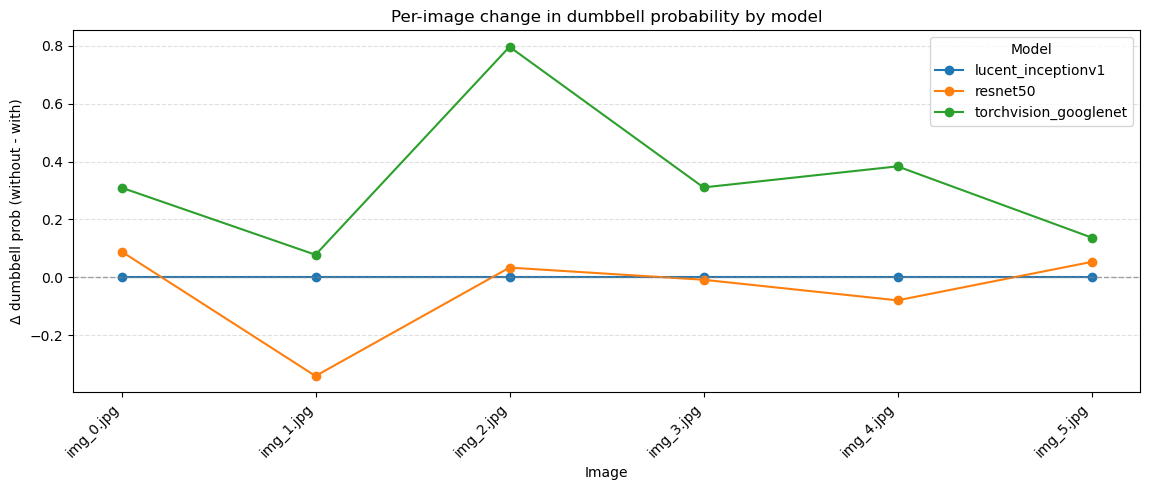

In [6]:
heat = df.pivot(index="model", columns="image", values="delta_dumbbell_prob")

images = list(heat.columns)
x = list(range(len(images)))
cmap = plt.get_cmap('tab10')

plt.figure(figsize=(1.6 * len(images) + 2, 5))
for idx, model_name in enumerate(heat.index):
    deltas = heat.loc[model_name].values
    plt.plot(x, deltas, marker='o', label=model_name, color=cmap(idx % cmap.N))

plt.axhline(0, color='gray', lw=1, linestyle='--', alpha=0.7)
plt.xticks(x, images, rotation=45, ha='right')
plt.ylabel('Δ dumbbell prob (without - with)')
plt.xlabel('Image')
plt.title('Per-image change in dumbbell probability by model')
plt.legend(title='Model')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


## Per‑model bar charts (with vs without arms)

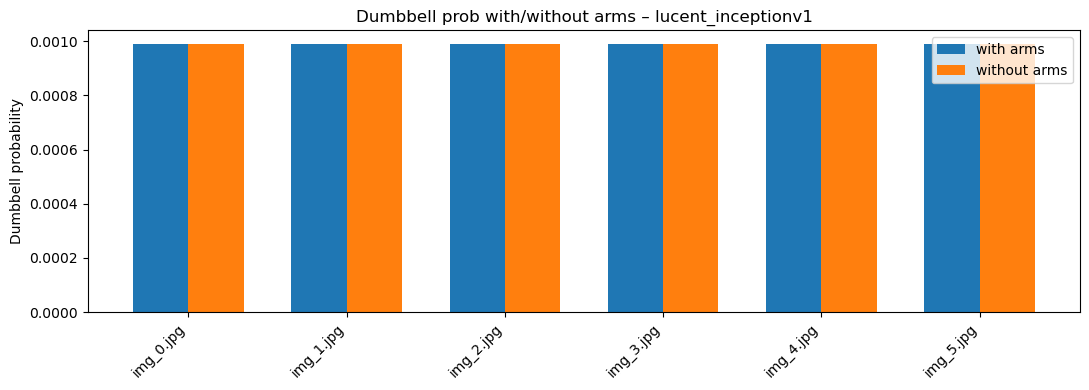

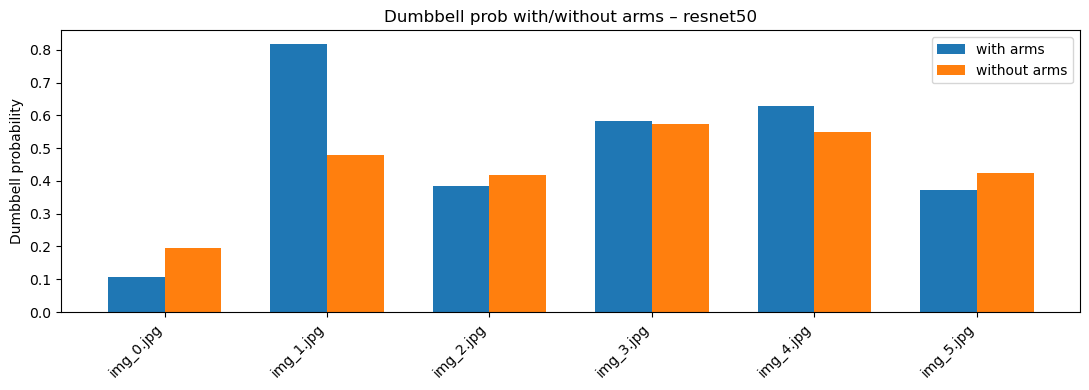

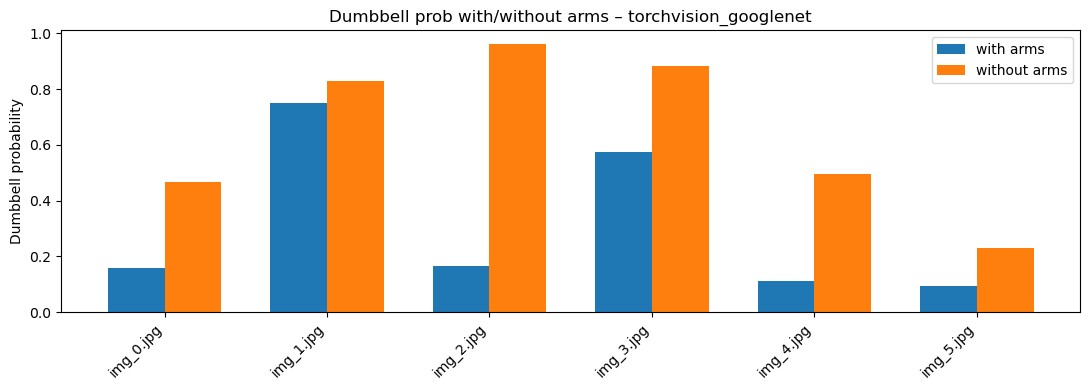

In [7]:
for model_name in heat.index:
    sub = df[df["model"] == model_name].copy()
    sub = sub.set_index("image").loc[heat.columns]  # same order as heatmap

    x = list(range(len(sub)))
    width = 0.35

    plt.figure(figsize=(1.5 * len(sub) + 2, 4))
    plt.bar([i - width / 2 for i in x],
            sub["with_dumbbell_prob"],
            width=width,
            label="with arms")
    plt.bar([i + width / 2 for i in x],
            sub["without_dumbbell_prob"],
            width=width,
            label="without arms")

    plt.xticks(x, sub.index, rotation=45, ha="right")
    plt.ylabel("Dumbbell probability")
    plt.title(f"Dumbbell prob with/without arms – {model_name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

## View predictions table

In [8]:
df[[
    "image",
    "model",
    "with_top1_label",
    "with_top1_prob",
    "without_top1_label",
    "without_top1_prob",
    "with_dumbbell_prob",
    "without_dumbbell_prob",
    "delta_dumbbell_prob",
]]


,image,model,with_top1_label,with_top1_prob,without_top1_label,without_top1_prob,with_dumbbell_prob,without_dumbbell_prob,delta_dumbbell_prob
0,img_0.jpg,lucent_inceptionv1,"567 frying pan, frypan, skillet",0.002688,class_1000,0.002651,0.000990,0.000990,2.374873e-08
1,img_0.jpg,resnet50,"571 gas pump, gasoline pump, petrol pump, isla...",0.111914,543 dumbbell,0.195692,0.106638,0.195692,8.905459e-02
2,img_0.jpg,torchvision_googlenet,543 dumbbell,0.156167,543 dumbbell,0.465828,0.156167,0.465828,3.096601e-01
3,img_1.jpg,lucent_inceptionv1,class_1000,0.002651,class_1000,0.002645,0.000990,0.000990,4.656613e-09
4,img_1.jpg,resnet50,543 dumbbell,0.818650,543 dumbbell,0.477863,0.818650,0.477863,-3.407866e-01
5,img_1.jpg,torchvision_googlenet,543 dumbbell,0.750892,543 dumbbell,0.828775,0.750892,0.828775,7.788289e-02
6,img_2.jpg,lucent_inceptionv1,"575 golfcart, golf cart",0.002575,class_1000,0.002692,0.000990,0.000990,-7.543713e-08
7,img_2.jpg,resnet50,543 dumbbell,0.385482,543 dumbbell,0.419088,0.385482,0.419088,3.360596e-02
8,img_2.jpg,torchvision_googlenet,543 dumbbell,0.166452,543 dumbbell,0.962605,0.166452,0.962605,7.961528e-01
9,img_3.jpg,lucent_inceptionv1,class_1000,0.002681,class_1000,0.002692,0.000990,0.000990,-7.450581e-09
